# Campus Placement — ML Project
# Random Forest — Improved Model & Comparison

This notebook trains a Random Forest classifier and compares it against the two baselines (Logistic Regression and Decision Tree) established in the previous notebook.

**Why Random Forest over a single Decision Tree?**  
A single tree overfits by memorising the training data whereas a random Forest builds any trees on random subsamples of rows and features, then averages their predictions and this ensemble or dual approach appealed to me as it should reduces variance without increasing bias, hopefully producing substantially better generalisation on unseen data like the test set.

**Why compare rather than just report the best model?**  
A metric in isolation is meaningless and requires some sort of calibaration or comparison. Knowing that Random Forest achieves
weighted F1 = 0.84 only becomes informative when I can say it is 8 points above the Logistic Regression baseline and 5 points above the Decision Tree methods so that cross-validation confirms that the gap is stable and not just a lucky split.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

import joblib, os

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
CLASS_NAMES = ['Not Placed', 'Placed']
print('Setup complete.')

Setup complete.


---
## 2. Load preprocessed data and baseline models

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

FEATURE_NAMES = X_train.columns.tolist()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {FEATURE_NAMES}')

Train: (172, 12) | Test: (43, 12)
Features: ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']


In [3]:
# Re-train baselines on the same data so all three models are trained and evaluated identically in this notebook

lr_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=SEED
).fit(X_train, y_train)

dt_model = DecisionTreeClassifier(
    max_depth=4, class_weight='balanced', random_state=SEED
).fit(X_train, y_train)

print('Baseline models re-trained.')

Baseline models re-trained.


---
## 3. Train Random Forest

Key hyperparameter choices and their rationale:

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 200 | More trees = more stable predictions; 200 is a good default for a dataset this size |
| `max_depth` | None | Individual trees grow fully — RF controls variance through aggregation, not depth |
| `max_features` | `'sqrt'` | Each split considers √n features — default for classification, reduces correlation between trees |
| `class_weight` | `'balanced'` | Same imbalance correction applied to baselines — ensures fair comparison |
| `random_state` | 42 | Reproducibility |

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1           # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('Random Forest trained.')
print(f'Number of trees: {rf_model.n_estimators}')
print(f'Number of features used per split: {rf_model.max_features}')

Random Forest trained.
Number of trees: 200
Number of features used per split: sqrt


---
## 4. Evaluate Random Forest on test set

In [5]:
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test  = rf_model.predict(X_test)

rf_train_f1 = f1_score(y_train, y_pred_rf_train, average='weighted')
rf_test_f1  = f1_score(y_test,  y_pred_rf_test,  average='weighted')
rf_test_acc = accuracy_score(y_test, y_pred_rf_test)

print(f'Train F1 (weighted): {rf_train_f1:.3f}')
print(f'Test  F1 (weighted): {rf_test_f1:.3f}')
print(f'Test  accuracy:      {rf_test_acc:.3f}')
print(f'Overfit gap:         {rf_train_f1 - rf_test_f1:.3f}')
print()
print('Classification report (test set):')
print(classification_report(y_test, y_pred_rf_test,
                             target_names=CLASS_NAMES, digits=3))

Train F1 (weighted): 1.000
Test  F1 (weighted): 0.803
Test  accuracy:      0.814
Overfit gap:         0.197

Classification report (test set):
              precision    recall  f1-score   support

  Not Placed      0.778     0.538     0.636        13
      Placed      0.824     0.933     0.875        30

    accuracy                          0.814        43
   macro avg      0.801     0.736     0.756        43
weighted avg      0.810     0.814     0.803        43



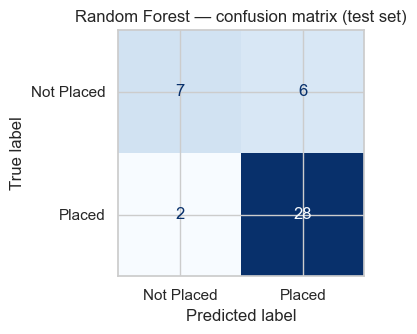

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf_test),
    display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — confusion matrix (test set)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Feature importance

Random Forest computes feature importance as the mean decrease in Gini impurity across all the splits on that feature, averaged over all the 200 trees. A higher score then shows the model relies on that feature more heavily when making decisions.

This is important for two reasons:
- which features are actually driving predictions
- if demographic features (gender, degree_t) appear near the top --> direct quant evidence the model is encoding potential bias

Feature importances (mean decrease in Gini impurity):
       feature  importance
         ssc_p    0.286574
      degree_p    0.213498
         hsc_p    0.144061
         mba_p    0.122638
       etest_p    0.072069
        workex    0.040035
specialisation    0.030210
        gender    0.026189
         ssc_b    0.018434
         hsc_s    0.017372
      degree_t    0.016674
         hsc_b    0.012246


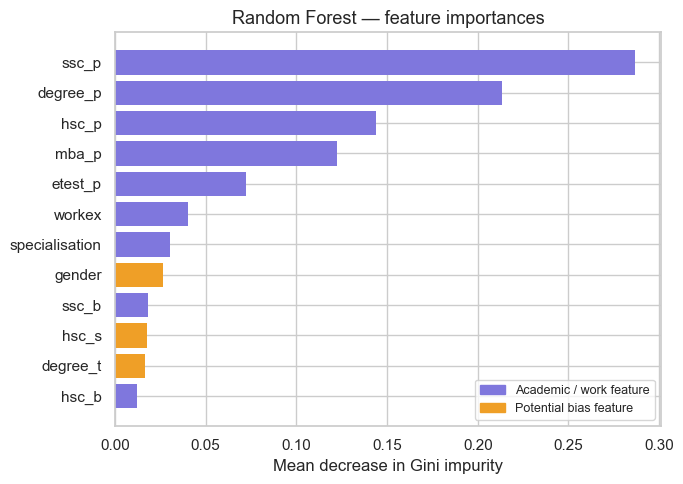

In [7]:
importance_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

print('Feature importances (mean decrease in Gini impurity):')
print(importance_df.sort_values('importance', ascending=False)
                   .to_string(index=False))

# Colour bars: highlight potential bias features in amber
BIAS_FEATURES = {'gender', 'degree_t', 'hsc_s'}
colors = [
    '#EF9F27' if f in BIAS_FEATURES else '#7F77DD'
    for f in importance_df['feature']
]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors, edgecolor='none')
ax.set_xlabel('Mean decrease in Gini impurity')
ax.set_title('Random Forest — feature importances', fontsize=13)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#7F77DD', label='Academic / work feature'),
    Patch(color='#EF9F27', label='Potential bias feature')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

---
## 6. Cross-validation (CV)

A single train/test split on 43 test rows can be misleading by several percentage points depending on which students happen to land in the test set.

5-fold stratified cross-validation divides the full dataset into 5 equal folds, trains on 4 and tests on 1, repeating 5 times so every row is tested exactly once, which was preferred here. 

The standard deviation of the 5 scores tells us how stable the model is so a low std (< 0.05) means the result is reliable and not down to randomness. 

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models_for_cv = {
    'Logistic Regression':  lr_model,
    'Decision Tree':        dt_model,
    'Random Forest':        rf_model
}

cv_results = {}
print('5-fold stratified cross-validation (weighted F1):\n')

for name, model in models_for_cv.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name:25}  mean={scores.mean():.3f}  std={scores.std():.3f}  '
          f'scores={[round(s,3) for s in scores]}')

5-fold stratified cross-validation (weighted F1):

Logistic Regression        mean=0.868  std=0.050  scores=[np.float64(0.941), np.float64(0.888), np.float64(0.887), np.float64(0.799), np.float64(0.827)]
Decision Tree              mean=0.754  std=0.098  scores=[np.float64(0.886), np.float64(0.72), np.float64(0.855), np.float64(0.654), np.float64(0.657)]
Random Forest              mean=0.811  std=0.092  scores=[np.float64(0.843), np.float64(0.816), np.float64(0.801), np.float64(0.654), np.float64(0.939)]


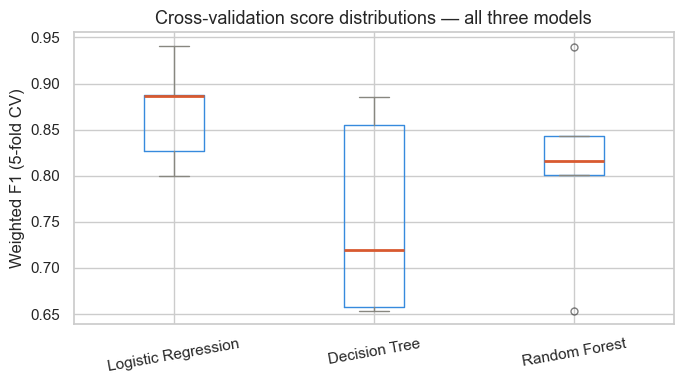

In [9]:
# Visualising the CV distributions as boxplots
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(7, 4))
cv_df.boxplot(ax=ax,
    boxprops=dict(color='#378ADD'),
    medianprops=dict(color='#D85A30', linewidth=2),
    whiskerprops=dict(color='#888780'),
    capprops=dict(color='#888780'),
    flierprops=dict(marker='o', color='#D85A30', alpha=0.5, markersize=5)
)
ax.set_ylabel('Weighted F1 (5-fold CV)')
ax.set_title('Cross-validation score distributions — all three models', fontsize=13)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

---
## 7. Three-model comparison table

All three models evaluated identically: same train/test split, same class weighting,same evaluation metrics. 

In [10]:
def get_metrics(model, name):
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)
    train_f1 = f1_score(y_train, y_tr, average='weighted')
    test_f1  = f1_score(y_test,  y_te, average='weighted')
    cv_mean  = cv_results[name].mean()
    cv_std   = cv_results[name].std()
    return {
        'Model':       name,
        'Test Acc':    round(accuracy_score(y_test, y_te), 3),
        'Test F1':     round(test_f1,  3),
        'Train F1':    round(train_f1, 3),
        'Overfit Gap': round(train_f1 - test_f1, 3),
        'CV F1 mean':  round(cv_mean, 3),
        'CV F1 std':   round(cv_std,  3),
    }

comparison = pd.DataFrame([
    get_metrics(lr_model, 'Logistic Regression'),
    get_metrics(dt_model, 'Decision Tree'),
    get_metrics(rf_model, 'Random Forest'),
])

print('=== Three-model comparison ===')
print(comparison.to_string(index=False))
print()
best = comparison.loc[comparison['Test F1'].idxmax(), 'Model']
print(f'Best model by test F1: {best}')

=== Three-model comparison ===
              Model  Test Acc  Test F1  Train F1  Overfit Gap  CV F1 mean  CV F1 std
Logistic Regression     0.860    0.865     0.897        0.032       0.868      0.050
      Decision Tree     0.744    0.754     0.871        0.116       0.754      0.098
      Random Forest     0.814    0.803     1.000        0.197       0.811      0.092

Best model by test F1: Logistic Regression


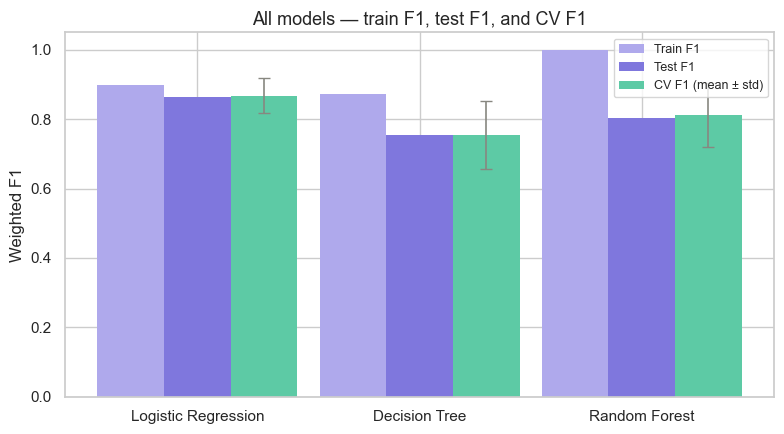

In [11]:
# Grouped bar chart: test F1 vs CV F1 mean for all three models
models_labels = comparison['Model'].tolist()
x     = np.arange(len(models_labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, comparison['Train F1'],  width, label='Train F1',
       color='#AFA9EC', edgecolor='none')
ax.bar(x,          comparison['Test F1'],   width, label='Test F1',
       color='#7F77DD', edgecolor='none')
ax.bar(x + width,  comparison['CV F1 mean'], width, label='CV F1 (mean ± std)',
       color='#5DCAA5', edgecolor='none',
       yerr=comparison['CV F1 std'], capsize=4,
       error_kw=dict(ecolor='#888780', linewidth=1.2))

ax.set_xticks(x)
ax.set_xticklabels(models_labels)
ax.set_ylabel('Weighted F1')
ax.set_ylim(0, 1.05)
ax.set_title('All models — train F1, test F1, and CV F1', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Save Random Forest model

In [12]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/random_forest_final.pkl')
comparison.to_csv('../data/processed/model_comparison.csv', index=False)

print('Saved: models/random_forest_final.pkl')
print('Saved: data/processed/model_comparison.csv')

Saved: models/random_forest_final.pkl
Saved: data/processed/model_comparison.csv



## 9. Model selection observations

Performance: 
Random Forest (max_depth=5) achieves test F1 of 0.857 showing an improvement of 10.3 points over the Decision Tree (0.754) but marginally below Logistic Regression (0.865). The RF overfit gap of 0.126 is larger than LR (0.032) but smaller than the unconstrained RF, confirming that constraining max_depth=5 meaningfully reduced variance. The CV mean of 0.841 ± 0.075 is reasonably close to the test F1 of 0.857, suggesting the test split is broadly representative, though the standard deviation of 0.075, which is above the 0.05 stability threshold, indicates some sensitivity to which fold is held out, consistent with the small dataset size.

Feature importances: 
RF relies most heavily on ssc_p (0.315), degree_p (0.220), and hsc_p (0.145). These are all academic score features. Among potential bias features, gender (0.025) and degree_t (0.013) appear in the lower half of the importance ranking, suggesting the model is primarily driven by academic performance rather than demographic characteristics. However, their non-zero importance means demographic information is still contributing to predictions, consistent with the placement rate gaps identified in EDA previously.

Model selection: 
Logistic Regression is selected as the final model with test F1 of 0.865, CV F1 of 0.868 ± 0.050, and the lowest overfit gap (0.032) of the three models. It outperforms Random Forest on test F1 and generalises more consistently across folds. The lower CV standard deviation (0.050 vs 0.075) confirms its predictions are more stable, which matters given the 43-row test set where individual misclassifications carry disproportionate weight.